<a href="https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/07_convolutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#|default_exp conv

In [57]:
%%capture
!mkdir -p miniai
!wget -O miniai/training.py https://raw.githubusercontent.com/fastai/course22p2/master/miniai/training.py
!wget -O miniai/datasets.py https://raw.githubusercontent.com/fastai/course22p2/master/miniai/datasets.py
!mkdir -p images
!wget -O images/grizzly.jpg https://raw.githubusercontent.com/fastai/course22p2/master/nbs/images/grizzly.jpg

# Convolutions

In [3]:
#|export
import torch
from torch import nn

from torch.utils.data import default_collate
from typing import Mapping

from miniai.training import *
from miniai.datasets import *

import pickle,gzip,math,os,time,shutil,torch,matplotlib as mpl, numpy as np
import pandas as pd,matplotlib.pyplot as plt
from pathlib import Path
from torch import tensor

from torch.utils.data import DataLoader
from typing import Mapping

mpl.rcParams['image.cmap'] = 'gray'

In [4]:
MNIST_URL='https://github.com/mnielsen/neural-networks-and-deep-learning/blob/master/data/mnist.pkl.gz?raw=true'
path_data = Path('data')
path_data.mkdir(exist_ok=True)
path_gz = path_data/'mnist.pkl.gz'

from urllib.request import urlretrieve
if not path_gz.exists(): urlretrieve(MNIST_URL, path_gz)

with gzip.open(path_gz, 'rb') as f: ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding='latin-1')
x_train, y_train, x_valid, y_valid = map(tensor, [x_train, y_train, x_valid, y_valid])

In the context of an image, a feature is a visually distinctive attribute. For example, the number 7 is characterized by a horizontal edge near the top of the digit, and a top-right to bottom-left diagonal edge underneath that.

It turns out that finding the edges in an image is a very common task in computer vision, and is surprisingly straightforward. To do it, we use a *convolution*. A convolution requires nothing more than multiplication, and addition.

### Understanding the Convolution Equations

To explain the math behind convolutions, fast.ai student Matt Kleinsmith came up with the very clever idea of showing [CNNs from different viewpoints](https://medium.com/impactai/cnns-from-different-viewpoints-fab7f52d159c).

Here's the input:

<img alt="The image" width="75" src="https://raw.githubusercontent.com/fastai/course22p2/master/nbs/images/att_00032.png">

Here's our kernel:

<img alt="The kernel" width="55" src="https://raw.githubusercontent.com/fastai/course22p2/master/nbs/images/att_00033.png">

Since the filter fits in the image four times, we have four results:

<img alt="The activations" width="52" src="https://raw.githubusercontent.com/fastai/course22p2/master/nbs/images/att_00034.png">

<img alt="Applying the kernel" width="366" caption="Applying the kernel" id="apply_kernel" src="https://raw.githubusercontent.com/fastai/course22p2/master/nbs/images/att_00035.png">

<img alt="The equation" width="436" caption="The equation" id="eq_view" src="https://raw.githubusercontent.com/fastai/course22p2/master/nbs/images/att_00036.png">

In [5]:
x_imgs = x_train.view(-1,28,28)
xv_imgs = x_valid.view(-1,28,28)

In [6]:
mpl.rcParams['figure.dpi'] = 30

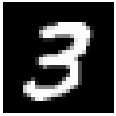

In [7]:
im3 = x_imgs[7]
show_image(im3);

In [8]:
top_edge = tensor([[-1,-1,-1],
                   [ 0, 0, 0],
                   [ 1, 1, 1]]).float()

We're going to call this our kernel (because that's what fancy computer vision researchers call these).

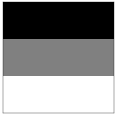

In [9]:
show_image(top_edge, noframe=False);

The filter will take any window of size 3×3 in our images, and if we name the pixel values like this:

$$\begin{matrix} a1 & a2 & a3 \\ a4 & a5 & a6 \\ a7 & a8 & a9 \end{matrix}$$

it will return $-a1-a2-a3+a7+a8+a9$.

In [10]:
df = pd.DataFrame(im3[:13,:23])
df.style.format(precision=2).set_properties(**{'font-size':'7pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.15,0.17,0.41,1.00,0.99,0.99,0.99,0.99,0.99,0.68,0.02,0.00
6,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.17,0.54,0.88,0.88,0.98,0.99,0.98,0.98,0.98,0.98,0.98,0.98,0.62,0.05
7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.70,0.98,0.98,0.98,0.98,0.99,0.98,0.98,0.98,0.98,0.98,0.98,0.98,0.23
8,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.43,0.98,0.98,0.90,0.52,0.52,0.52,0.52,0.74,0.98,0.98,0.98,0.98,0.23
9,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.11,0.11,0.09,0.00,0.00,0.00,0.00,0.05,0.88,0.98,0.98,0.67,0.03


In [11]:
(im3[3:6,14:17] * top_edge).sum()

tensor(2.9727)

In [12]:
(im3[7:10,14:17] * top_edge).sum()

tensor(-2.9570)

In [13]:
def apply_kernel(row, col, kernel): return (im3[row-1:row+2,col-1:col+2] * kernel).sum()

In [14]:
apply_kernel(4,15,top_edge)

tensor(2.9727)

<img src="https://raw.githubusercontent.com/fastai/course22p2/master/nbs/images/chapter9_nopadconv.svg" id="nopad_conv" caption="Applying a kernel across a grid" alt="Applying a kernel across a grid" width="400">

In [15]:
[[(i,j) for j in range(5)] for i in range(5)]

[[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4)],
 [(1, 0), (1, 1), (1, 2), (1, 3), (1, 4)],
 [(2, 0), (2, 1), (2, 2), (2, 3), (2, 4)],
 [(3, 0), (3, 1), (3, 2), (3, 3), (3, 4)],
 [(4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]]

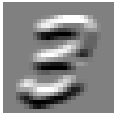

In [16]:
rng = range(1,27)
top_edge3 = tensor([[apply_kernel(i,j,top_edge) for j in rng] for i in rng])
show_image(top_edge3);

In [17]:
left_edge = tensor([[-1,0,1],
                    [-1,0,1],
                    [-1,0,1]]).float()

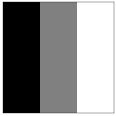

In [18]:
show_image(left_edge, noframe=False);

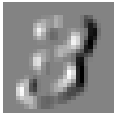

In [19]:
left_edge3 = tensor([[apply_kernel(i,j,left_edge) for j in rng] for i in rng])
show_image(left_edge3);

<img alt="Result of applying a 3×3 kernel to a 4×4 image" width="782" caption="Result of applying a 3×3 kernel to a 4×4 image (courtesy of Vincent Dumoulin and Francesco Visin)" id="three_ex_four_conv" src="https://raw.githubusercontent.com/fastai/course22p2/master/nbs/images/att_00028.png">

### Convolutions in PyTorch

In [20]:
import torch.nn.functional as F
import torch

What to do if you have [2 months to complete your thesis](https://github.com/Yangqing/caffe/wiki/Convolution-in-Caffe:-a-memo)? Use [im2col](https://hal.inria.fr/inria-00112631/).

im2col is a way of converting a
convolution into a matrix multiply

so this is a basically a way
of unrolling
um your kernels and your input features
into matrices such as when you do the
Matrix multiply you get the right answer

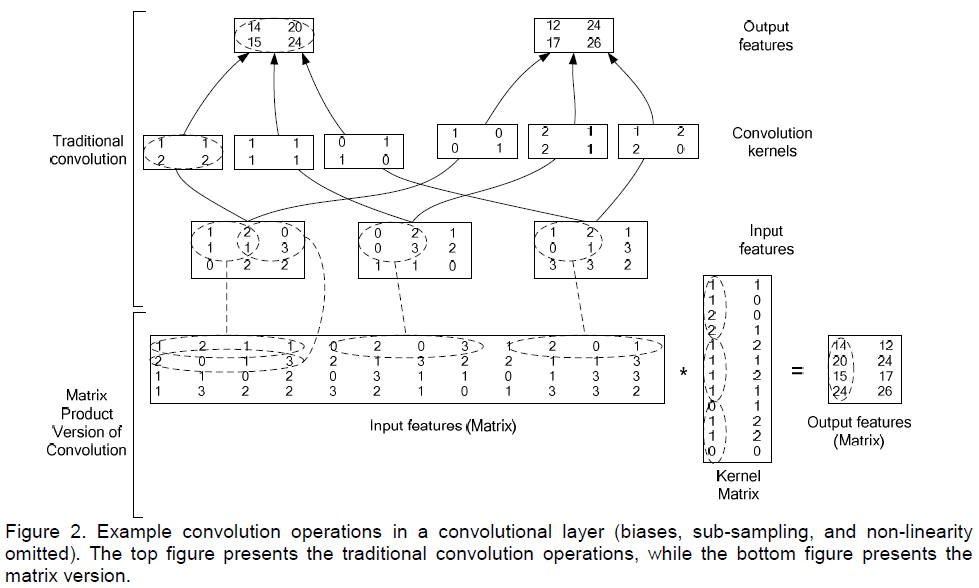

這張圖應該是 input channel:3, output channel:2

Here's a sample [numpy implementation](https://github.com/3outeille/CNNumpy/blob/5394f13e7ed67a808a3e39fd381f168825d65ff5/src/fast/utils.py#L360).

(unfold 運作方式：
- 對每個 3x3 的滑動視窗（不使用 padding, stride=1 預設）
- 每個 patch 展平成長度 9 的向量
- 覆蓋整個影像：左上角往右下角滑動)

這代表什麼？
- 每個 patch 展平成一個 9 維向量（即 3x3）
- 共有 676 個 patch
  - 28 - 3 + 1 = 26 → 26 x 26 = 676)

In [21]:
inp = im3[None,None,:,:].float() # batch, channel dimension
inp_unf = F.unfold(inp, (3,3))[0]
inp_unf.shape

torch.Size([9, 676])

In [22]:
w = left_edge.view(-1)
w.shape

torch.Size([9])

In [23]:
out_unf = w@inp_unf
out_unf.shape

torch.Size([676])

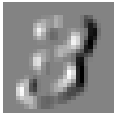

In [24]:
out = out_unf.view(26,26)
show_image(out);

In [25]:
%timeit -n 1 tensor([[apply_kernel(i,j,left_edge) for j in rng] for i in rng]);

17.3 ms ± 1.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [26]:
%timeit -n 100 (w@F.unfold(inp, (3,3))[0]).view(26,26);

81.9 µs ± 8.42 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [27]:
%timeit -n 100 F.conv2d(inp, left_edge[None,None])

The slowest run took 5.45 times longer than the fastest. This could mean that an intermediate result is being cached.
42.4 µs ± 33 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [28]:
diag1_edge = tensor([[ 0,-1, 1],
                     [-1, 1, 0],
                     [ 1, 0, 0]]).float()

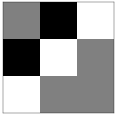

In [29]:
show_image(diag1_edge, noframe=False);

In [30]:
diag2_edge = tensor([[ 1,-1, 0],
                     [ 0, 1,-1],
                     [ 0, 0, 1]]).float()

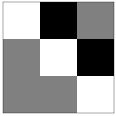

In [31]:
show_image(diag2_edge, noframe=False);

[torch.nn.functional.conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.conv2d.html)
```python
torch.nn.functional.conv2d(
  input, # shape: (N, C_in, H, W)
  weight, # shape: (C_out, C_in // groups, kH, kW)
  bias=None,
  stride=1,
  padding=0,
  dilation=1,
  groups=1
)
```
(預設情況 (groups=1)：
- 每個輸出通道都會接收到所有輸入通道的資訊。

分組卷積 (groups > 1)：
- 會把 in_channels 和 out_channels 分成多組，讓每組只跟特定的輸入通道子集相連。
  - 權重的 shape 變成 (C_out, C_in // groups, kH, kW)
  - 每個 group 的輸入通道和對應的權重只會與特定的輸出通道連結。

groups = 2
- in_channels = 4, out_channels = 6
- 就會變成兩組：
  - 第一組處理前兩個輸入通道，對應到前 3 個輸出通道
  - 第二組處理後兩個輸入通道，對應到後 3 個輸出通道)

In [32]:
xb = x_imgs[:16][:,None]
xb.shape

torch.Size([16, 1, 28, 28])

In [33]:
edge_kernels = torch.stack([left_edge, top_edge, diag1_edge, diag2_edge])[:,None]
edge_kernels.shape

torch.Size([4, 1, 3, 3])

In [34]:
batch_features = F.conv2d(xb, edge_kernels)
batch_features.shape

torch.Size([16, 4, 26, 26])

The output shape shows we gave 16 images in the mini-batch, 4 kernels, and 26×26 edge maps (we started with 28×28 images, but lost one pixel from each side as discussed earlier). We can see we get the same results as when we did this manually:

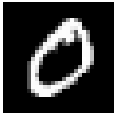

In [35]:
img0 = xb[1,0]
show_image(img0);

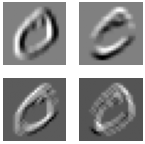

In [36]:
show_images([batch_features[1,i] for i in range(4)])

### Strides and Padding

With appropriate padding, we can ensure that the output activation map is the same size as the original image.

<img src="https://raw.githubusercontent.com/fastai/course22p2/master/nbs/images/chapter9_padconv.svg" id="pad_conv" caption="A convolution with padding" alt="A convolution with padding" width="600">

With a 5×5 input, 4×4 kernel, and 2 pixels of padding, we end up with a 6×6 activation map.

even numbered Edge kernels are not used
very often we normally used odd numbered
kernels if you use for example a three
by three kernel
and one pixel of padding you will get
back the same size you start with if you
use five by five
with three pixels of padding you'll end
up with the same size you start with so
generally odd numbered Edge size kernels
are easier to deal with to make sure you
end up with the same thing you start
with

<img alt="A 4×4 kernel with 5×5 input and 2 pixels of padding" width="783" caption="A 4×4 kernel with 5×5 input and 2 pixels of padding (courtesy of Vincent Dumoulin and Francesco Visin)" id="four_by_five_conv" src="https://raw.githubusercontent.com/fastai/course22p2/master/nbs/images/att_00029.png">

If we add a kernel of size `ks` by `ks` (with `ks` an odd number), the necessary padding on each side to keep the same shape is `ks//2`.

We could move over two pixels after each kernel application. This is known as a *stride-2* convolution.

stride-2 convolutions
are handy because they actually reduce
the dimensionality of your input
by a factor of 2

<img alt="A 3×3 kernel with 5×5 input, stride-2 convolution, and 1 pixel of padding" width="774" caption="A 3×3 kernel with 5×5 input, stride-2 convolution, and 1 pixel of padding (courtesy of Vincent Dumoulin and Francesco Visin)" id="three_by_five_conv" src="https://raw.githubusercontent.com/fastai/course22p2/master/nbs/images/att_00030.png">

## Creating the CNN

In [37]:
n,m = x_train.shape
c = y_train.max()+1
nh = 50

In [38]:
model = nn.Sequential(nn.Linear(m,nh), nn.ReLU(), nn.Linear(nh,10))

[classtorch.nn.Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
- in_channels, out_channels, kernel_size, stride=1, padding=0

In [39]:
broken_cnn = nn.Sequential(
    nn.Conv2d(1,30, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(30,10, kernel_size=3, padding=1)
)

In [40]:
broken_cnn(xb).shape

torch.Size([16, 10, 28, 28])

In [41]:
#|export
def conv(ni, nf, ks=3, stride=2, act=True):
    res = nn.Conv2d(ni, nf, stride=stride, kernel_size=ks, padding=ks//2)
    if act: res = nn.Sequential(res, nn.ReLU())
    return res

Refactoring parts of your neural networks like this makes it much less likely you'll get errors due to inconsistencies in your architectures, and makes it more obvious to the reader which parts of your layers are actually changing.

In [42]:
simple_cnn = nn.Sequential(
    conv(1 ,4),            #14x14
    conv(4 ,8),            #7x7
    conv(8 ,16),           #4x4
    conv(16,16),           #2x2
    conv(16,10, act=False), #1x1
    nn.Flatten(),
)

(一般情況下： 如果 generator expression 是唯一的引數，就 不用加括號。)
```python
sum(o.numel() for o in simple_cnn.parameters())
```


In [43]:
simple_cnn(xb).shape

torch.Size([16, 10])

In [44]:
x_imgs = x_train.view(-1,1,28,28)
xv_imgs = x_valid.view(-1,1,28,28)
train_ds,valid_ds = Dataset(x_imgs, y_train),Dataset(xv_imgs, y_valid)

if you've got a
Apple silicon Mac you've got a device
called MPS which is going to use the
your max GPU or if you've got Nvidia you
can use Cuda which we'll use your Nvidia
GPU the coders
you know 10 times or more possibly much
more faster than a Mac so you definitely
want to use Nvidia if you can

(`type(x)(...)` 把這些結果 用原本的容器型別組起來)

In [45]:
#|export
def_device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'

def to_device(x, device=def_device):
    if isinstance(x, torch.Tensor): return x.to(device)
    if isinstance(x, Mapping): return {k:v.to(device) for k,v in x.items()}
    return type(x)(to_device(o, device) for o in x)

def collate_device(b): return to_device(default_collate(b))

In [46]:
from torch import optim

bs = 256
lr = 0.4
train_dl,valid_dl = get_dls(train_ds, valid_ds, bs, collate_fn=collate_device)
opt = optim.SGD(simple_cnn.parameters(), lr=lr)

In [47]:
loss,acc = fit(5, simple_cnn.to(def_device), F.cross_entropy, opt, train_dl, valid_dl)

0 0.537900085401535 0.8198000000953675
1 0.20647021322250367 0.9343999994277954
2 0.16619348697662353 0.9462000001907349
3 0.11308478279113769 0.9654999992370605
4 0.1141672828912735 0.9658000005722046


In [48]:
opt = optim.SGD(simple_cnn.parameters(), lr=lr/4)
loss,acc = fit(5, simple_cnn.to(def_device), F.cross_entropy, opt, train_dl, valid_dl)

0 0.08775614993572235 0.9734999994277954
1 0.0849524807214737 0.9742999995231628
2 0.08853767011165618 0.9745000007629394
3 0.0820580258846283 0.9760999995231628
4 0.08609852228164673 0.9752000007629394


### Understanding Convolution Arithmetic

In an input of size `64x1x28x28` the axes are `batch,channel,height,width`. This is often represented as `NCHW` (where `N` refers to batch size). Tensorflow, on the other hand, uses `NHWC` axis order (aka "channels-last"). Channels-last is faster for many models, so recently it's become more common to see this as an option in PyTorch too.

We have 1 input channel, 4 output channels, and a 3×3 kernel.

In [49]:
simple_cnn[0][0]

Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))

In [50]:
conv1 = simple_cnn[0][0]
conv1.weight.shape

torch.Size([4, 1, 3, 3])

In [51]:
conv1.bias.shape

torch.Size([4])

The *receptive field* is the area of an image that is involved in the calculation of a layer. *conv-example.xlsx* shows the calculation of two stride-2 convolutional layers using an MNIST digit. Here's what we see if we click on one of the cells in the *conv2* section, which shows the output of the second convolutional layer, and click *trace precedents*.

<img alt="Immediate precedents of conv2 layer" width="308" caption="Immediate precedents of Conv2 layer" id="preced1" src="https://raw.githubusercontent.com/fastai/course22p2/master/nbs/images/att_00068.png?raw=1">

The blue highlighted cells are its *precedents*—that is, the cells used to calculate its value. These cells are the corresponding 3×3 area of cells from the input layer (on the left), and the cells from the filter (on the right). Click *trace precedents* again:

<img alt="Secondary precedents of conv2 layer" width="601" caption="Secondary precedents of Conv2 layer" id="preced2" src="https://raw.githubusercontent.com/fastai/course22p2/master/nbs/images/att_00069.png?raw=1">

In this example, we have just two convolutional layers. We can see that a 7×7 area of cells in the input layer is used to calculate the single green cell in the Conv2 layer. This is the *receptive field*

The deeper we are in the network (specifically, the more stride-2 convs we have before a layer), the larger the receptive field for an activation in that layer.

## Color Images

A colour picture is a rank-3 tensor:

In [52]:
from torchvision.io import read_image

In [58]:
im = read_image('images/grizzly.jpg')
im.shape

torch.Size([3, 1000, 846])

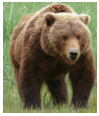

In [59]:
show_image(im.permute(1,2,0));

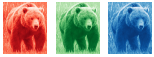

In [60]:
_,axs = plt.subplots(1,3)
for bear,ax,color in zip(im,axs,('Reds','Greens','Blues')): show_image(255-bear, ax=ax, cmap=color)

<img src="https://raw.githubusercontent.com/fastai/course22p2/master/nbs/images/chapter9_rgbconv.svg?raw=1" id="rgbconv" caption="Convolution over an RGB image" alt="Convolution over an RGB image" width="550">

These are then all added together, to produce a single number, for each grid location, for each output feature.

<img src="https://raw.githubusercontent.com/fastai/course22p2/master/nbs/images/chapter9_rgb_conv_stack.svg?raw=1" id="rgbconv2" caption="Adding the RGB filters" alt="Adding the RGB filters" width="500">

We have `ch_out` filters like this, so in the end, the result of our convolutional layer will be a batch of images with `ch_out` channels.